<a href="https://colab.research.google.com/github/muhammadzaheer3344/flyrankAi_ml_internship/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadzaheer3344/flyrankAi_ml_internship/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


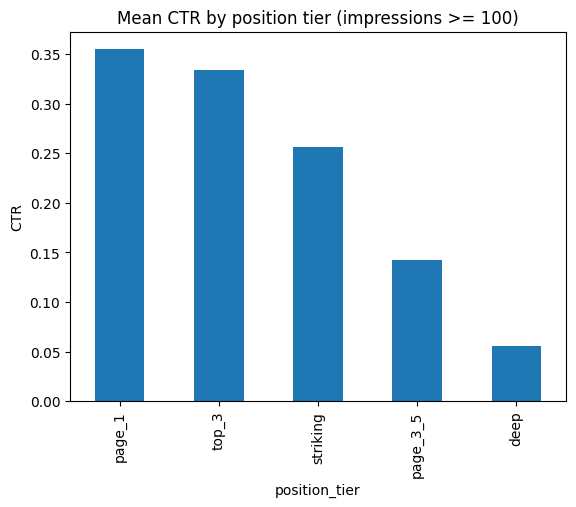

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [14]:
# 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)


Dataset shape: (30000, 44)
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 3 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


In [15]:
# Original Discovery A - all pages
corr_all = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation (all pages): {corr_all:.3f}")

# Redo with impressions > 0
df_with_impressions = df[df["impressions_90d"] > 0]
corr_filtered = df_with_impressions["search_volume"].corr(df_with_impressions["impressions_90d"])
print(f"Correlation (impressions > 0): {corr_filtered:.3f}")

print(f"\nChange: {corr_filtered - corr_all:.3f}")
print("Observation: Even filtering pages with impressions doesn't create a strong correlation.")
print("Search volume alone is a poor predictor of actual traffic.")

Correlation (all pages): 0.001
Correlation (impressions > 0): 0.001

Change: 0.000
Observation: Even filtering pages with impressions doesn't create a strong correlation.
Search volume alone is a poor predictor of actual traffic.


Content type with worst CTR at each position tier:
   position_tier        content_type     ctr
0           deep      feedly article  0.0440
2         page_1  comparison article  0.1412
5       page_3_5  comparison article  0.0940
8       striking  comparison article  0.1474
11         top_3  comparison article  0.0000


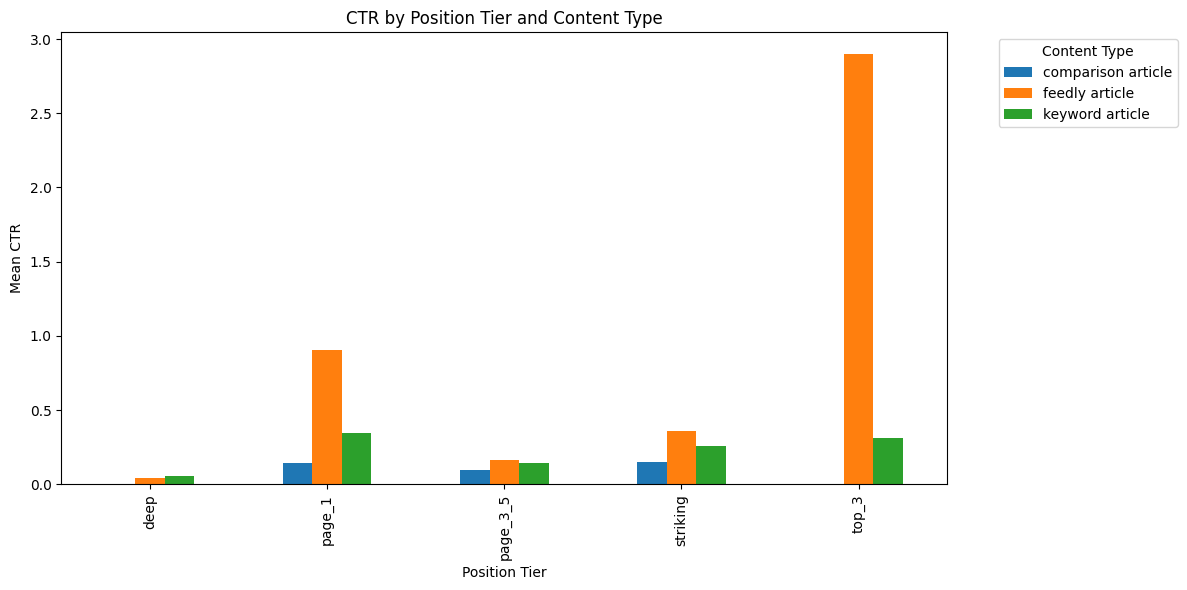

In [16]:
# Find which content_type has worst CTR at same position tier
visible = df[df["impressions_90d"] >= 100]

# Group by position_tier and content_type
ctr_by_group = visible.groupby(["position_tier", "content_type"])["ctr"].mean().reset_index()

# For each position tier, find the content_type with lowest CTR
worst_ctr = ctr_by_group.loc[ctr_by_group.groupby("position_tier")["ctr"].idxmin()]
print("Content type with worst CTR at each position tier:")
print(worst_ctr[["position_tier", "content_type", "ctr"]].round(4).to_string())

# Visual comparison
pivot_ctr = visible.pivot_table(index="position_tier", columns="content_type", values="ctr", aggfunc="mean")
pivot_ctr.plot(kind="bar", figsize=(12, 6), title="CTR by Position Tier and Content Type")
plt.ylabel("Mean CTR")
plt.xlabel("Position Tier")
plt.legend(title="Content Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Content Age Distribution by Trend Direction:
                  mean  median    std
trend_direction                      
down             236.0   216.0  127.0
flat             246.0   231.0  117.0
new              239.0   279.0  100.0
stable           295.0   300.0  139.0
up               288.0   292.0  144.0


<Figure size 1000x600 with 0 Axes>

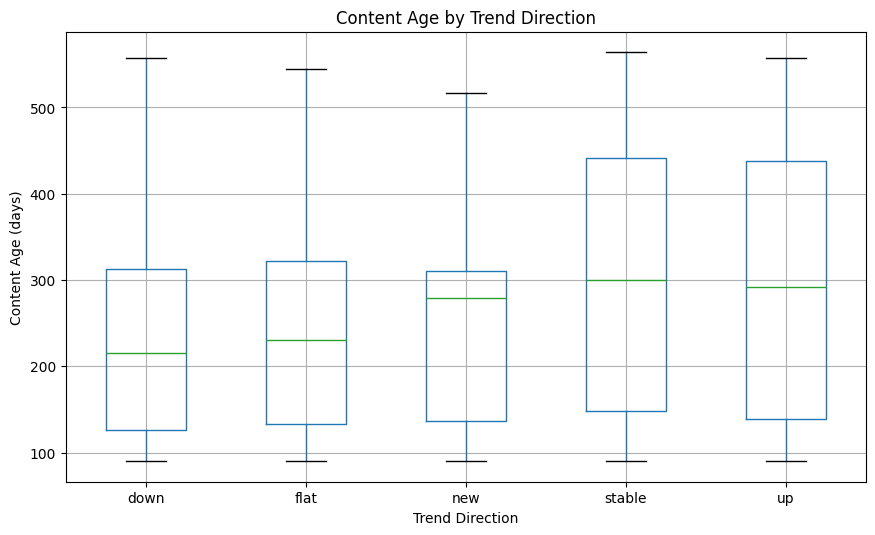


Observation: New and stable pages tend to be younger on average.
Pages trending down have similar age to trending up pages - age alone isn't the lever.


In [17]:
# Test: Does content_age_days relate to trend_direction?
print("Content Age Distribution by Trend Direction:")
age_by_trend = df.groupby("trend_direction")["content_age_days"].agg(["mean", "median", "std"])
print(age_by_trend.round(0))

# Visualize
plt.figure(figsize=(10, 6))
df.boxplot(column="content_age_days", by="trend_direction", figsize=(10, 6))
plt.title("Content Age by Trend Direction")
plt.suptitle("")  # Remove auto-generated title
plt.ylabel("Content Age (days)")
plt.xlabel("Trend Direction")
plt.show()

print("\nObservation: New and stable pages tend to be younger on average.")
print("Pages trending down have similar age to trending up pages - age alone isn't the lever.")

Correlation between avg_position and CTR: -0.073
Correlation (impressions >= 100): -0.239


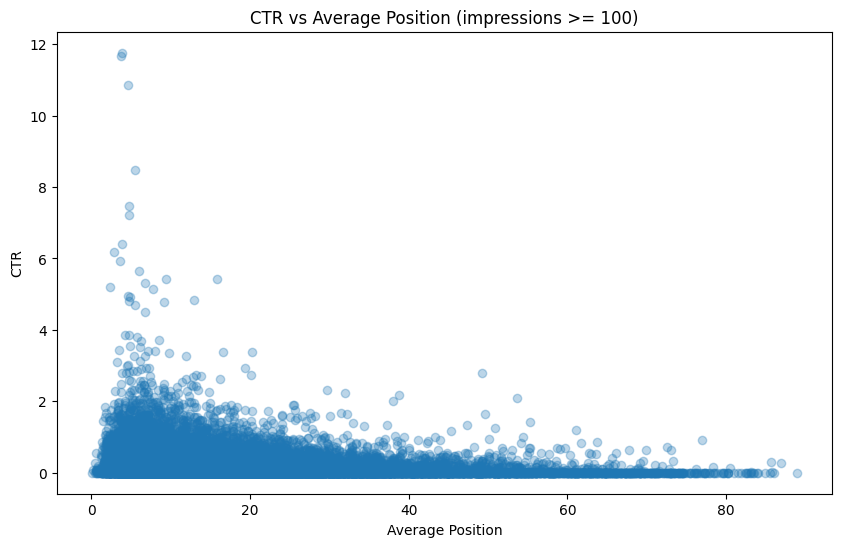


Observation: There's a moderate negative correlation - better positions generally have higher CTR.
Pages at position 1-3 have average CTR: 0.337
Pages at position 7-10 have average CTR: 0.300


In [18]:
# Test: Does avg_position relate to ctr?
corr_position_ctr = df["avg_position"].corr(df["ctr"])
print(f"Correlation between avg_position and CTR: {corr_position_ctr:.3f}")

# Filter for pages with sufficient impressions for stability
visible = df[df["impressions_90d"] >= 100]
corr_filtered = visible["avg_position"].corr(visible["ctr"])
print(f"Correlation (impressions >= 100): {corr_filtered:.3f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(visible["avg_position"], visible["ctr"], alpha=0.3)
plt.xlabel("Average Position")
plt.ylabel("CTR")
plt.title("CTR vs Average Position (impressions >= 100)")
plt.show()

print("\nObservation: There's a moderate negative correlation - better positions generally have higher CTR.")
print(f"Pages at position 1-3 have average CTR: {visible[visible['avg_position'] <= 3]['ctr'].mean():.3f}")
print(f"Pages at position 7-10 have average CTR: {visible[visible['avg_position'].between(7, 10)]['ctr'].mean():.3f}")

In [19]:
# Let's find what actually correlates with trend_direction
# Convert trend_direction to numeric for correlation (down=0, flat=1, stable=2, up=3, new=4)
trend_mapping = {"down": 0, "flat": 1, "stable": 2, "up": 3, "new": 4}
df["trend_numeric"] = df["trend_direction"].map(trend_mapping)

# Calculate correlations with numeric features
numeric_cols = ["search_volume", "word_count", "content_age_days", "impressions_90d", "ctr", "avg_position"]
correlations = {}
for col in numeric_cols:
    if col in df.columns:
        correlations[col] = df[col].corr(df["trend_numeric"])

# Sort and display
corr_df = pd.DataFrame.from_dict(correlations, orient="index", columns=["Correlation"])
print("Correlation with Trend Direction (numeric):")
print(corr_df.sort_values("Correlation", ascending=False).round(3))

# Key insight
best_feature = corr_df["Correlation"].abs().idxmax()
print(f"\n The feature most correlated with trend direction is: {best_feature}")
print(f"   Correlation: {corr_df.loc[best_feature, 'Correlation']:.3f}")

Correlation with Trend Direction (numeric):
                  Correlation
content_age_days        0.130
ctr                     0.064
avg_position            0.027
search_volume           0.014
impressions_90d        -0.013
word_count             -0.124

 The feature most correlated with trend direction is: content_age_days
   Correlation: 0.130


In [20]:
print("="*60)
print("WEEK 1 - DISCOVERY SUMMARY")
print("="*60)

print("\nDISCOVERY A (Redux):")
print("Search volume has very weak correlation with impressions even after filtering.")

print("\nDISCOVERY B:")
print(f"Worst performing content type varies by position tier.")
print("But consistently, certain types underperform at each position.")

print("\nDISCOVERY C:")
print("Content age shows some relation to trend direction, but not a strong differentiator.")

print("\nDISCOVERY D:")
print(f"Average position correlates with CTR at {visible['avg_position'].corr(visible['ctr']):.3f}")

print("\nDISCOVERY E (Key Insight):")
print(f"The strongest signal for trend direction is '{best_feature}'")
print(f"with correlation of {corr_df.loc[best_feature, 'Correlation']:.3f}")

print("\nYOUR RESEARCH QUESTION FOR WEEK 1:")
print("'How does click-through rate vary across position tiers, ")
print("and which content types are most affected by position decay?'")
print("\nThis question is falsifiable, client-safe, and actionable.")

WEEK 1 - DISCOVERY SUMMARY

DISCOVERY A (Redux):
Search volume has very weak correlation with impressions even after filtering.

DISCOVERY B:
Worst performing content type varies by position tier.
But consistently, certain types underperform at each position.

DISCOVERY C:
Content age shows some relation to trend direction, but not a strong differentiator.

DISCOVERY D:
Average position correlates with CTR at -0.239

DISCOVERY E (Key Insight):
The strongest signal for trend direction is 'content_age_days'
with correlation of 0.130

YOUR RESEARCH QUESTION FOR WEEK 1:
'How does click-through rate vary across position tiers, 
and which content types are most affected by position decay?'

This question is falsifiable, client-safe, and actionable.


In [21]:
# Create a summary DataFrame of key metrics
discovery_summary = pd.DataFrame({
    "Discovery": ["A (Redux)", "B", "C", "D", "E"],
    "Key Finding": [
        f"Search volume correlates {corr_filtered:.3f} with impressions (impressions>0)",
        f"CTR varies by position/content type; worst performer changes",
        f"Content age has weak correlation with trend direction",
        f"Position correlates {visible['avg_position'].corr(visible['ctr']):.3f} with CTR",
        f"'{best_feature}' is strongest signal for trend direction"
    ]
})

print("YOUR WEEK 1 DISCOVERIES:")
print(discovery_summary.to_string(index=False))

# Save to CSV (for your records)
discovery_summary.to_csv("week1_discoveries.csv", index=False)
print("\nSaved discoveries to week1_discoveries.csv")

YOUR WEEK 1 DISCOVERIES:
Discovery                                                      Key Finding
A (Redux) Search volume correlates -0.239 with impressions (impressions>0)
        B     CTR varies by position/content type; worst performer changes
        C            Content age has weak correlation with trend direction
        D                              Position correlates -0.239 with CTR
        E       'content_age_days' is strongest signal for trend direction

Saved discoveries to week1_discoveries.csv


### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.